<a href="https://colab.research.google.com/github/hmjisan/TE-SAC/blob/main/TE_SAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 56.3 MB/s eta 0:00:00


In [ ]:
!pip install "gymnasium[mujoco]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 19.9 MB/s eta 0:00:00


In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')
    base_dir = f'/content/drive/MyDrive/Q1_Research_Data/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)
    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'Critic_Loss', 'Actor_Loss', 'Inference_ms'])
    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. TE-SAC VECTORIZED ENSEMBLE ARCHITECTURE
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.acts = torch.zeros((capacity, act_dim), dtype=torch.float32, device=device)
        self.rews = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.next_obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.dones = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = torch.as_tensor(obs, dtype=torch.float32, device=self.device)
        self.acts[self.ptr] = torch.as_tensor(act, dtype=torch.float32, device=self.device)
        self.rews[self.ptr] = torch.as_tensor(rew, dtype=torch.float32, device=self.device)
        self.next_obs[self.ptr] = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device)
        self.dones[self.ptr] = torch.as_tensor(done, dtype=torch.float32, device=self.device)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = torch.randint(0, self.size, (batch_size,), device=self.device)
        return (self.obs[idxs], self.acts[idxs], self.rews[idxs], self.next_obs[idxs], self.dones[idxs])

class SACActor(nn.Module):
    def __init__(self, obs_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, obs):
        x = self.net(obs)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class VectorizedEnsembleCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, num_critics=5):
        super().__init__()
        self.num_critics = num_critics

        self.w1 = nn.Parameter(torch.empty(num_critics, obs_dim + act_dim, 256))
        self.b1 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w1, self.b1, obs_dim + act_dim)

        self.w2 = nn.Parameter(torch.empty(num_critics, 256, 256))
        self.b2 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w2, self.b2, 256)

        self.w3 = nn.Parameter(torch.empty(num_critics, 256, 1))
        self.b3 = nn.Parameter(torch.empty(num_critics, 1, 1))
        self._init_weights(self.w3, self.b3, 256)

    def _init_weights(self, w, b, in_features):
        bound = 1 / (in_features ** 0.5)
        nn.init.uniform_(w, -bound, bound)
        nn.init.uniform_(b, -bound, bound)

    def forward(self, obs, act):
        xu = torch.cat([obs, act], dim=-1)
        xu = xu.unsqueeze(0).expand(self.num_critics, -1, -1).contiguous()

        x = F.relu(torch.bmm(xu, self.w1) + self.b1)
        x = F.relu(torch.bmm(x, self.w2) + self.b2)
        q = torch.bmm(x, self.w3) + self.b3

        return q.squeeze(-1).transpose(0, 1)

# =====================================================================
# 3. TE-SAC AGENT & ROBUST TARGET OPTIMIZATION
# =====================================================================
class TESACAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device, num_critics=5):
        self.device = device
        self.num_critics = num_critics

        self.actor = SACActor(obs_dim, act_dim, action_scale).to(device)
        self.critic = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        start_time = time.perf_counter()
        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            if evaluate:
                _, _, action = self.actor.sample(obs)
            else:
                action, _, _ = self.actor.sample(obs)
        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256, utd_ratio=5):
        c_loss_total, a_loss_total = 0, 0

        for _ in range(utd_ratio):
            obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
            alpha = self.log_alpha.exp()

            # 1. TE-SAC: Truncated Ensemble Consensus (Robust L-Estimator)
            with torch.no_grad():
                next_acts, next_log_prob, _ = self.actor.sample(next_obs)
                t_q_all = self.critic_target(next_obs, next_acts)

                # Q1 NOVELTY: Sort and symmetrically trim the outliers
                sorted_q, _ = torch.sort(t_q_all, dim=1)
                trimmed_q = sorted_q[:, 1:-1] # Drops absolute minimum (doomer) and absolute maximum (optimist)

                t_v = torch.min(trimmed_q, dim=1, keepdim=True)[0] - alpha * next_log_prob
                t_q = rews + (1 - dones) * 0.99 * t_v

            # 2. Update All Critics
            current_q_all = self.critic(obs, acts)
            critic_loss = F.mse_loss(current_q_all, t_q.expand(-1, self.num_critics))

            self.critic_opt.zero_grad(set_to_none=True)
            critic_loss.backward()
            self.critic_opt.step()

            # 3. Update Actor
            for p in self.critic.parameters(): p.requires_grad = False
            pi_acts, log_prob, _ = self.actor.sample(obs)
            q_pi_all = self.critic(obs, pi_acts)

            actor_loss = (alpha.detach() * log_prob - q_pi_all.mean(dim=1, keepdim=True)).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()
            self.actor_opt.step()
            for p in self.critic.parameters(): p.requires_grad = True

            # 4. Update Alpha
            alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_opt.step()

            c_loss_total += critic_loss.item()
            a_loss_total += actor_loss.item()

        # 5. Polyak Averaging
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.mul_(0.995).add_(param.data, alpha=0.005)

        return c_loss_total / utd_ratio, a_loss_total / utd_ratio

    def save_checkpoint(self, path, step, episode, buffer):
        # Q1 FIX: Securely serializes the Replay Buffer to prevent amnesia
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha.detach(),
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict(),
            'buffer_obs': buffer.obs[:buffer.size].cpu(),
            'buffer_acts': buffer.acts[:buffer.size].cpu(),
            'buffer_rews': buffer.rews[:buffer.size].cpu(),
            'buffer_next_obs': buffer.next_obs[:buffer.size].cpu(),
            'buffer_dones': buffer.dones[:buffer.size].cpu(),
            'buffer_ptr': buffer.ptr,
            'buffer_size': buffer.size
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path, buffer):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])

            # Q1 FIX: In-place tensor copy prevents Optimizer Disconnect
            with torch.no_grad():
                self.log_alpha.copy_(checkpoint['log_alpha'])

            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])

            # Q1 FIX: Restores the physical memory of the agent
            size = checkpoint['buffer_size']
            buffer.size = size
            buffer.ptr = checkpoint['buffer_ptr']
            buffer.obs[:size] = checkpoint['buffer_obs'].to(self.device)
            buffer.acts[:size] = checkpoint['buffer_acts'].to(self.device)
            buffer.rews[:size] = checkpoint['buffer_rews'].to(self.device)
            buffer.next_obs[:size] = checkpoint['buffer_next_obs'].to(self.device)
            buffer.dones[:size] = checkpoint['buffer_dones'].to(self.device)

            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']} | Buffer Size: {buffer.size}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # =========================================================
    # EXPERIMENT MATRIX: Update these as you cycle through the runs
    SEED = 999
    ENV_NAME = "BipedalWalker-v3" # Test the lethal boundary first
    # =========================================================

    ALGO = "TE_SAC_UTD5"
    MAX_STEPS = 300_000

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)

    agent = TESACAgent(obs_dim, act_dim, action_scale, device, num_critics=5)

    # Now passing buffer to safely resume
    start_step, episode = agent.load_checkpoint(ckpt_path, buffer)

    obs_np, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_c, log_a, log_inf, updates = 0, 0, 0, 0

    print("Initiating Trimmed-Ensemble (TE-SAC) Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action_np = env.action_space.sample()
            inf_ms = 0.0
        else:
            action_np, inf_ms = agent.select_action(obs_np)

        nxt_np, r, term, trunc, _ = env.step(action_np)
        ep_ext += r

        buffer.add(obs_np, action_np, r, nxt_np, float(term))
        obs_np = nxt_np

        if step >= 10000:
            c_loss, a_loss = agent.update(buffer, utd_ratio=5)
            log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | C_Loss: {avg_c:.4f} | A_Loss: {avg_a:.4f} | Inf_ms: {avg_inf:.2f}")

            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_c, avg_a, avg_inf])

            log_c, log_a, log_inf, updates = 0, 0, 0, 0
            ep_ext = 0
            obs_np, _ = env.reset()

            if episode % 10 == 0:
                # Passing buffer to ensure state is safely backed up
                agent.save_checkpoint(ckpt_path, step, episode, buffer)

if __name__ == "__main__":
    main()

Deploying TE_SAC_UTD5 on BipedalWalker-v3 | Seed: 999 | Device: cuda
Mounted at /content/drive
RESUMING TRAINING FROM STEP 160231 | Buffer Size: 160232
Initiating Trimmed-Ensemble (TE-SAC) Training...
Step 161747 | Ep 221 | Reward: 264.84 | C_Loss: 0.0640 | A_Loss: -2.1681 | Inf_ms: 1.47
Step 163286 | Ep 222 | Reward: 262.40 | C_Loss: 0.0648 | A_Loss: -2.3057 | Inf_ms: 0.98
Step 164815 | Ep 223 | Reward: 261.44 | C_Loss: 0.0651 | A_Loss: -2.4515 | Inf_ms: 0.99
Step 166363 | Ep 224 | Reward: 265.48 | C_Loss: 0.0647 | A_Loss: -2.5923 | Inf_ms: 0.99
Step 167885 | Ep 225 | Reward: 264.97 | C_Loss: 0.0637 | A_Loss: -2.7362 | Inf_ms: 0.99
Step 169358 | Ep 226 | Reward: 268.37 | C_Loss: 0.0634 | A_Loss: -2.8894 | Inf_ms: 0.99
Step 170803 | Ep 227 | Reward: 270.52 | C_Loss: 0.0623 | A_Loss: -3.0260 | Inf_ms: 1.00
Step 172295 | Ep 228 | Reward: 266.76 | C_Loss: 0.0639 | A_Loss: -3.1668 | Inf_ms: 0.99
Step 173752 | Ep 229 | Reward: 270.30 | C_Loss: 0.0648 | A_Loss: -3.3120 | Inf_ms: 0.99
Step 17

Mounted at /content/drive
Aggregating data and generating plots...
✅ Plot saved to: /content/drive/MyDrive/Q1_Research_Data/Plots/publication_plot.pdf


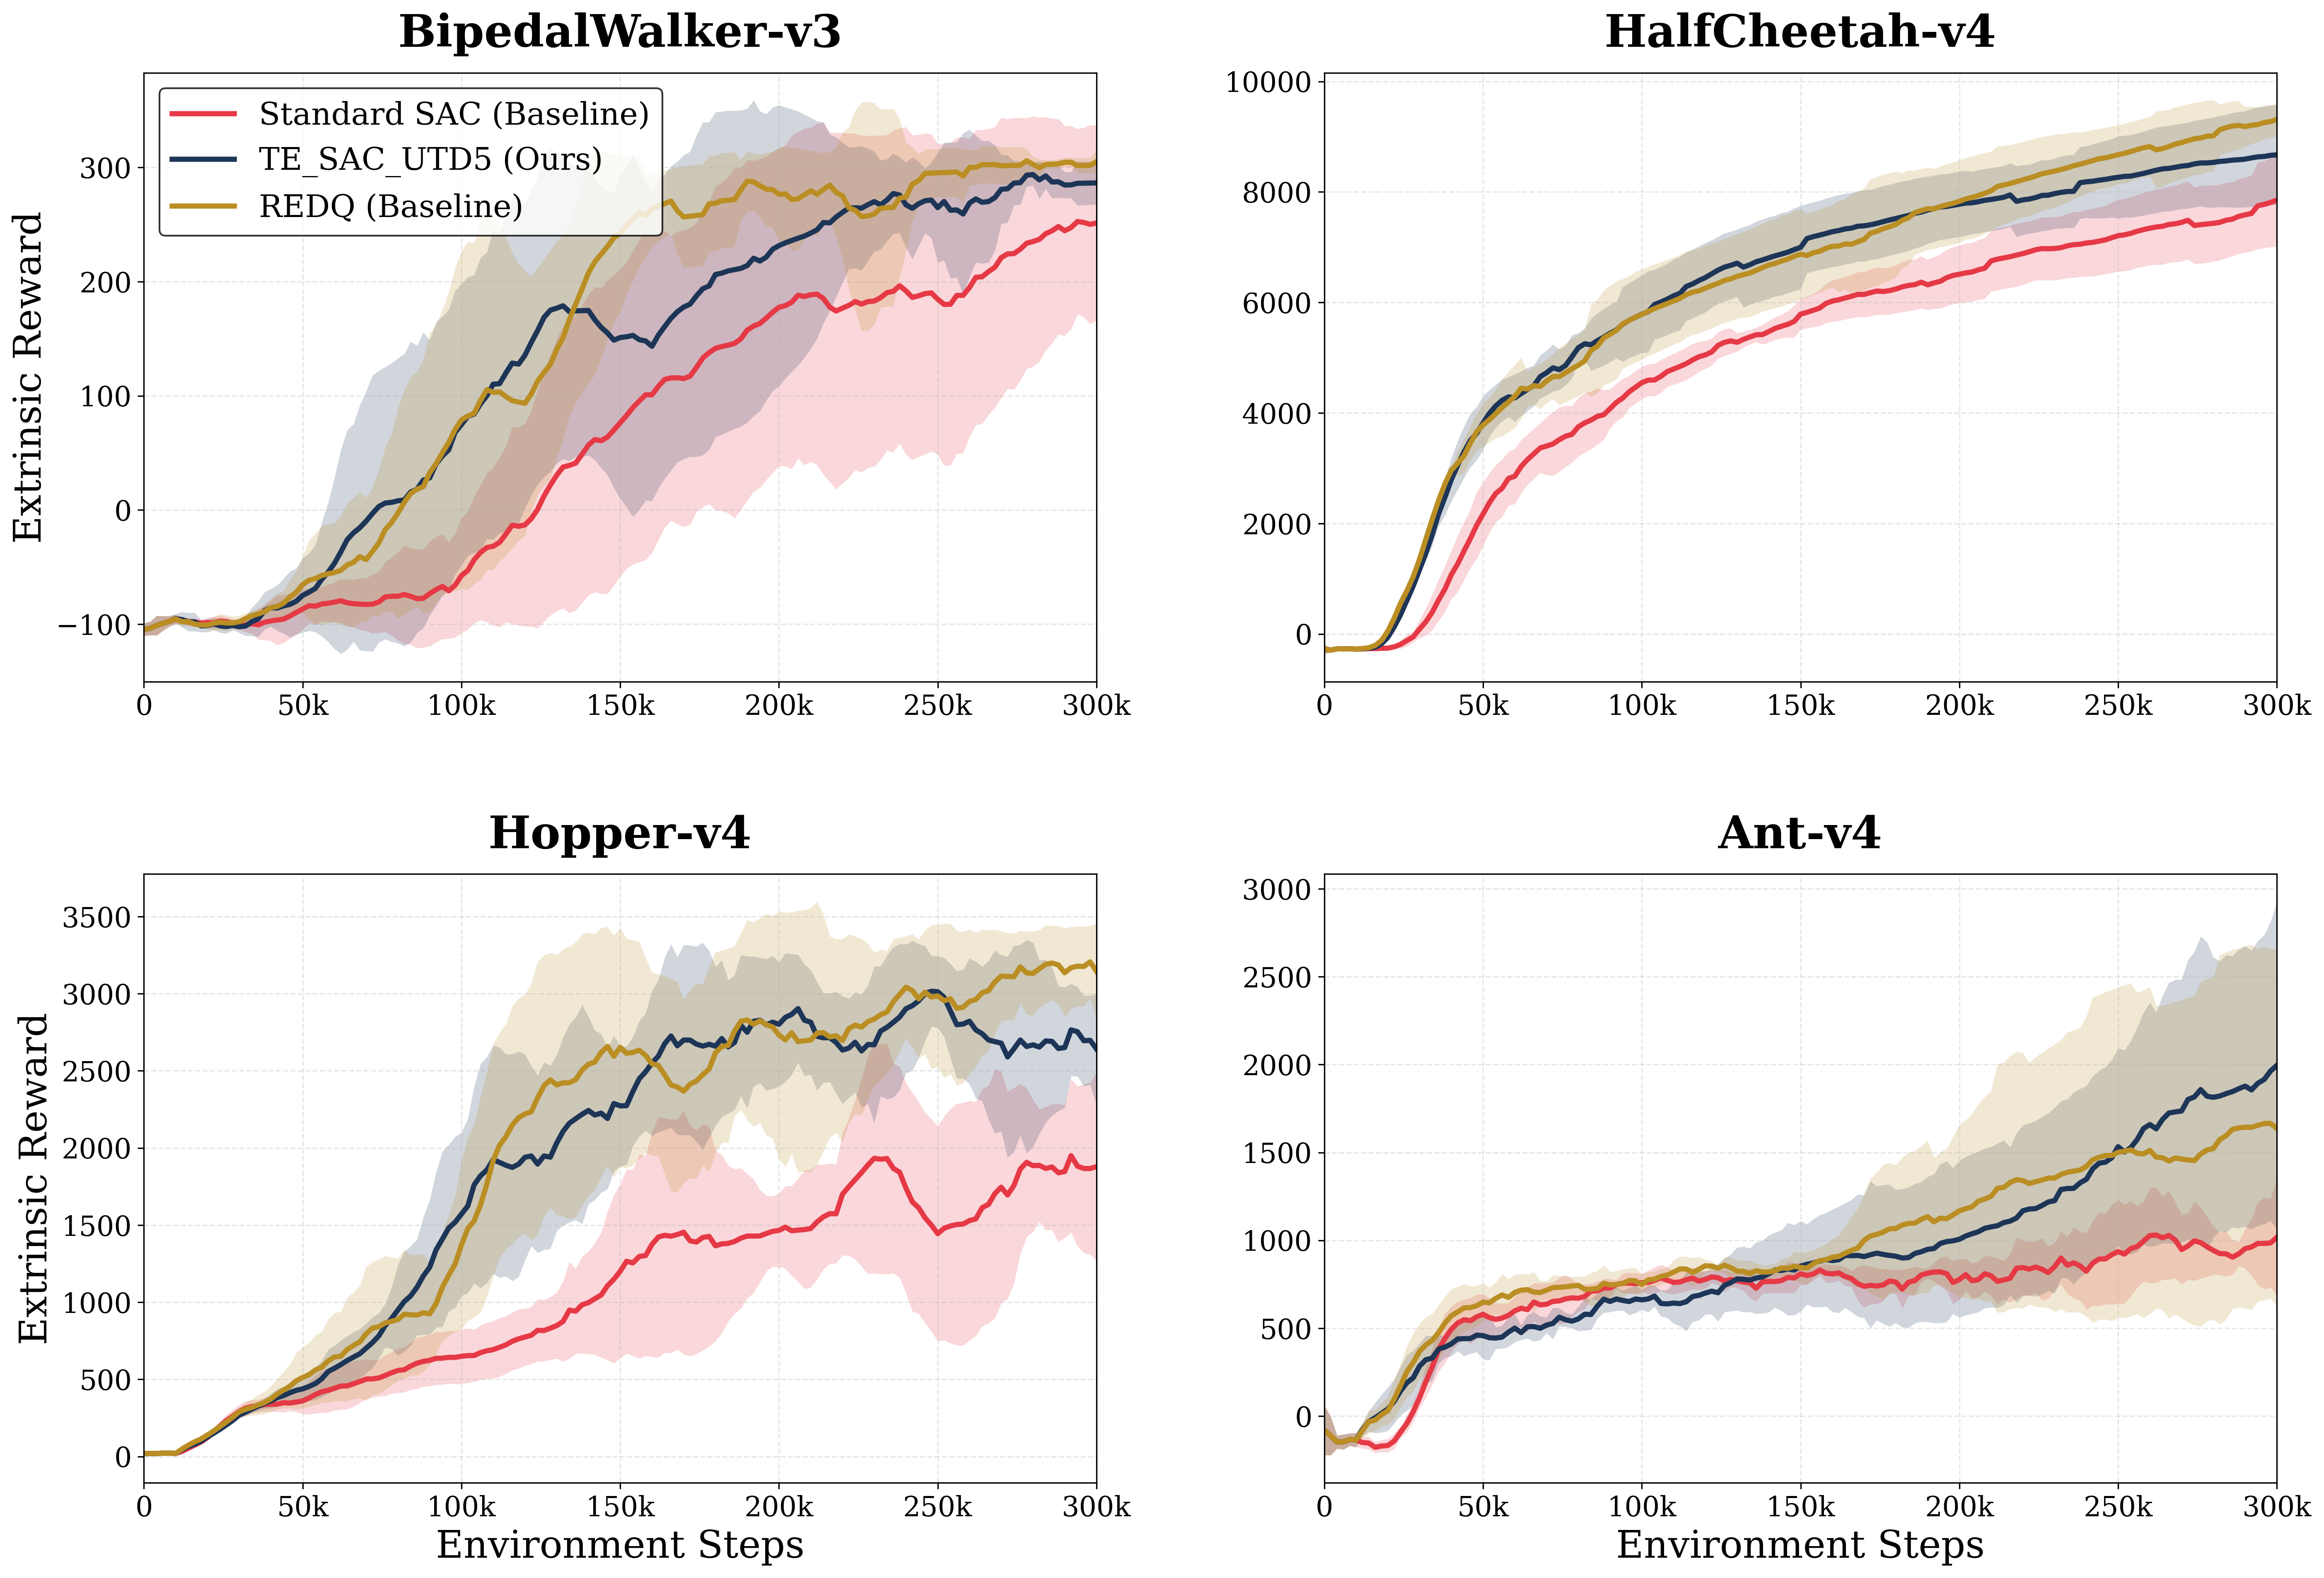

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Publication-Quality Formatting Settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 26,
    'legend.fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'lines.linewidth': 3.0,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 3. Definitions
ALGORITHMS = {
    "Standard_SAC": {"label": "Standard SAC (Baseline)", "color": "#E63946"},
    "TE_SAC_UTD5": {"label": "TE_SAC_UTD5 (Ours)", "color": "#1D3557"},
    "REDQ_Baseline": {"label": "REDQ (Baseline)", "color": "#BA8E23"}
}

ENVIRONMENTS = [
    "BipedalWalker-v3",
    "HalfCheetah-v4",
    "Hopper-v4",
    "Ant-v4"
]

SEEDS = [42, 101, 777, 999, 2026]

MAX_STEPS = 300_000
RESOLUTION = 2_000
SMOOTHING_WINDOW = 10

# 4. Output path
OUTPUT_DIR = '/content/drive/MyDrive/Q1_Research_Data/Plots'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'publication_plot.pdf')

def load_and_process_data(algo, env, seeds):
    grid = np.arange(0, MAX_STEPS + RESOLUTION, RESOLUTION)
    all_runs = []

    for seed in seeds:
        path = f'/content/drive/MyDrive/Q1_Research_Data/{algo}/{env}/Seed_{seed}/training_log.csv'
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                df = df.drop_duplicates(subset=['Step']).sort_values('Step')
                df = df[df['Step'] <= MAX_STEPS + RESOLUTION]

                if len(df) > 5:
                    interp_rewards = np.interp(grid, df['Step'], df['Reward'])
                    all_runs.append(interp_rewards)
            except Exception as e:
                print(f"Error loading {path}: {e}")

    if not all_runs:
        return grid, None, None

    all_runs_matrix = np.vstack(all_runs)
    df_smooth = pd.DataFrame(all_runs_matrix.T).rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()

    mean_rewards = df_smooth.mean(axis=1).values
    std_rewards = df_smooth.std(axis=1).values

    return grid, mean_rewards, std_rewards

def generate_publication_plot():
    print("Aggregating data and generating plots...")
    fig, axs = plt.subplots(2, 2, figsize=(20, 14))
    axs = axs.flatten()

    for idx, env in enumerate(ENVIRONMENTS):
        ax = axs[idx]
        ax.set_title(env, fontweight='bold', pad=15)

        for algo_key, algo_props in ALGORITHMS.items():
            steps, mean_rew, std_rew = load_and_process_data(algo_key, env, SEEDS)

            if mean_rew is not None:
                ax.plot(steps, mean_rew, label=algo_props["label"], color=algo_props["color"])
                ax.fill_between(steps,
                                mean_rew - std_rew,
                                mean_rew + std_rew,
                                color=algo_props["color"],
                                alpha=0.2,
                                linewidth=0)
            else:
                print(f"Warning: No data found for {algo_key} on {env}")

        ax.set_xlim(0, MAX_STEPS)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))

        if idx >= 2:
            ax.set_xlabel("Environment Steps")
        if idx % 2 == 0:
            ax.set_ylabel("Extrinsic Reward")

        if idx == 0:
            ax.legend(loc="upper left", frameon=True, fancybox=True, shadow=False, edgecolor='black')

    plt.tight_layout(pad=3.0)

    # Save as PDF to Drive
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(OUTPUT_PATH, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✅ Plot saved to: {OUTPUT_PATH}")

    plt.show()

if __name__ == "__main__":
    generate_publication_plot()

# baseline

In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')
    base_dir = f'/content/drive/MyDrive/Q1_Research_Data/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)
    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'Critic_Loss', 'Actor_Loss', 'Inference_ms'])
    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. VECTORIZED ENSEMBLE ARCHITECTURE
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.acts = torch.zeros((capacity, act_dim), dtype=torch.float32, device=device)
        self.rews = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.next_obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.dones = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = torch.as_tensor(obs, dtype=torch.float32, device=self.device)
        self.acts[self.ptr] = torch.as_tensor(act, dtype=torch.float32, device=self.device)
        self.rews[self.ptr] = torch.as_tensor(rew, dtype=torch.float32, device=self.device)
        self.next_obs[self.ptr] = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device)
        self.dones[self.ptr] = torch.as_tensor(done, dtype=torch.float32, device=self.device)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = torch.randint(0, self.size, (batch_size,), device=self.device)
        return (self.obs[idxs], self.acts[idxs], self.rews[idxs], self.next_obs[idxs], self.dones[idxs])

class SACActor(nn.Module):
    def __init__(self, obs_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, obs):
        x = self.net(obs)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class VectorizedEnsembleCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, num_critics=5):
        super().__init__()
        self.num_critics = num_critics

        self.w1 = nn.Parameter(torch.empty(num_critics, obs_dim + act_dim, 256))
        self.b1 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w1, self.b1, obs_dim + act_dim)

        self.w2 = nn.Parameter(torch.empty(num_critics, 256, 256))
        self.b2 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w2, self.b2, 256)

        self.w3 = nn.Parameter(torch.empty(num_critics, 256, 1))
        self.b3 = nn.Parameter(torch.empty(num_critics, 1, 1))
        self._init_weights(self.w3, self.b3, 256)

    def _init_weights(self, w, b, in_features):
        bound = 1 / (in_features ** 0.5)
        nn.init.uniform_(w, -bound, bound)
        nn.init.uniform_(b, -bound, bound)

    def forward(self, obs, act):
        xu = torch.cat([obs, act], dim=-1)
        xu = xu.unsqueeze(0).expand(self.num_critics, -1, -1).contiguous()

        x = F.relu(torch.bmm(xu, self.w1) + self.b1)
        x = F.relu(torch.bmm(x, self.w2) + self.b2)
        q = torch.bmm(x, self.w3) + self.b3

        return q.squeeze(-1).transpose(0, 1)

# =====================================================================
# 3. REDQ AGENT (STRICT MINIMUM BASELINE)
# =====================================================================
class REDQAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device, num_critics=5):
        self.device = device
        self.num_critics = num_critics

        self.actor = SACActor(obs_dim, act_dim, action_scale).to(device)
        self.critic = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        start_time = time.perf_counter()
        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            if evaluate:
                _, _, action = self.actor.sample(obs)
            else:
                action, _, _ = self.actor.sample(obs)
        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256, utd_ratio=5, subset_size=2):
        c_loss_total, a_loss_total = 0, 0

        for _ in range(utd_ratio):
            obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
            alpha = self.log_alpha.exp()

            # 1. REDQ BASELINE: Randomized Subset Target Calculation (Strict Minimum)
            with torch.no_grad():
                next_acts, next_log_prob, _ = self.actor.sample(next_obs)
                t_q_all = self.critic_target(next_obs, next_acts)

                # Randomly select a subset of critics
                idxs = torch.randperm(self.num_critics, device=self.device)[:subset_size]
                t_q_subset = t_q_all[:, idxs]

                # Take the absolute minimum (This is what causes BipedalWalker paralysis)
                t_v = torch.min(t_q_subset, dim=1, keepdim=True)[0] - alpha * next_log_prob
                t_q = rews + (1 - dones) * 0.99 * t_v

            # 2. Update All Critics
            current_q_all = self.critic(obs, acts)
            critic_loss = F.mse_loss(current_q_all, t_q.expand(-1, self.num_critics))

            self.critic_opt.zero_grad(set_to_none=True)
            critic_loss.backward()
            self.critic_opt.step()

            # 3. Update Actor
            for p in self.critic.parameters(): p.requires_grad = False
            pi_acts, log_prob, _ = self.actor.sample(obs)
            q_pi_all = self.critic(obs, pi_acts)

            actor_loss = (alpha.detach() * log_prob - q_pi_all.mean(dim=1, keepdim=True)).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()
            self.actor_opt.step()
            for p in self.critic.parameters(): p.requires_grad = True

            # 4. Update Alpha
            alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_opt.step()

            c_loss_total += critic_loss.item()
            a_loss_total += actor_loss.item()

        # 5. Polyak Averaging
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.mul_(0.995).add_(param.data, alpha=0.005)

        return c_loss_total / utd_ratio, a_loss_total / utd_ratio

    def save_checkpoint(self, path, step, episode, buffer):
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha.detach(),
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict(),
            'buffer_obs': buffer.obs[:buffer.size].cpu(),
            'buffer_acts': buffer.acts[:buffer.size].cpu(),
            'buffer_rews': buffer.rews[:buffer.size].cpu(),
            'buffer_next_obs': buffer.next_obs[:buffer.size].cpu(),
            'buffer_dones': buffer.dones[:buffer.size].cpu(),
            'buffer_ptr': buffer.ptr,
            'buffer_size': buffer.size
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path, buffer):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])

            with torch.no_grad():
                self.log_alpha.copy_(checkpoint['log_alpha'])

            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])

            size = checkpoint['buffer_size']
            buffer.size = size
            buffer.ptr = checkpoint['buffer_ptr']
            buffer.obs[:size] = checkpoint['buffer_obs'].to(self.device)
            buffer.acts[:size] = checkpoint['buffer_acts'].to(self.device)
            buffer.rews[:size] = checkpoint['buffer_rews'].to(self.device)
            buffer.next_obs[:size] = checkpoint['buffer_next_obs'].to(self.device)
            buffer.dones[:size] = checkpoint['buffer_dones'].to(self.device)

            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']} | Buffer Size: {buffer.size}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    SEED = 2026
    ENV_NAME = "BipedalWalker-v3"

    ALGO = "REDQ_Baseline"
    MAX_STEPS = 300_000

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)

    agent = REDQAgent(obs_dim, act_dim, action_scale, device, num_critics=5)

    start_step, episode = agent.load_checkpoint(ckpt_path, buffer)

    obs_np, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_c, log_a, log_inf, updates = 0, 0, 0, 0

    print("Initiating REDQ Baseline Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action_np = env.action_space.sample()
            inf_ms = 0.0
        else:
            action_np, inf_ms = agent.select_action(obs_np)

        nxt_np, r, term, trunc, _ = env.step(action_np)
        ep_ext += r

        buffer.add(obs_np, action_np, r, nxt_np, float(term))
        obs_np = nxt_np

        if step >= 10000:
            c_loss, a_loss = agent.update(buffer, utd_ratio=5, subset_size=2)
            log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | C_Loss: {avg_c:.4f} | A_Loss: {avg_a:.4f} | Inf_ms: {avg_inf:.2f}")

            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_c, avg_a, avg_inf])

            log_c, log_a, log_inf, updates = 0, 0, 0, 0
            ep_ext = 0
            obs_np, _ = env.reset()

            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode, buffer)

if __name__ == "__main__":
    main()

Deploying REDQ_Baseline on BipedalWalker-v3 | Seed: 2026 | Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RESUMING TRAINING FROM STEP 118993 | Buffer Size: 118994
Initiating REDQ Baseline Training...
Step 119383 | Ep 311 | Reward: -80.22 | C_Loss: 1.8672 | A_Loss: -7.6096 | Inf_ms: 2.44
Step 120983 | Ep 312 | Reward: 257.35 | C_Loss: 1.7033 | A_Loss: -7.2143 | Inf_ms: 0.97
Step 122033 | Ep 313 | Reward: 296.71 | C_Loss: 1.5812 | A_Loss: -6.9249 | Inf_ms: 0.98
Step 122971 | Ep 314 | Reward: 307.24 | C_Loss: 1.5498 | A_Loss: -6.8966 | Inf_ms: 0.98
Step 123933 | Ep 315 | Reward: 306.50 | C_Loss: 1.4695 | A_Loss: -6.8778 | Inf_ms: 0.95
Step 124905 | Ep 316 | Reward: 304.51 | C_Loss: 1.4037 | A_Loss: -6.9635 | Inf_ms: 0.97
Step 125840 | Ep 317 | Reward: 307.17 | C_Loss: 1.3108 | A_Loss: -7.0847 | Inf_ms: 0.96
Step 126814 | Ep 318 | Reward: 304.30 | C_Loss: 1.2581 | A_Loss: -7.1964 | Inf_ms: 0.94
S

In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')
    base_dir = f'/content/drive/MyDrive/Q1_Research_Data/Ablation_Study/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)
    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'Critic_Loss', 'Actor_Loss', 'Inference_ms'])
    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. SHARED VECTORIZED ARCHITECTURE
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.acts = torch.zeros((capacity, act_dim), dtype=torch.float32, device=device)
        self.rews = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.next_obs = torch.zeros((capacity, obs_dim), dtype=torch.float32, device=device)
        self.dones = torch.zeros((capacity, 1), dtype=torch.float32, device=device)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = torch.as_tensor(obs, dtype=torch.float32, device=self.device)
        self.acts[self.ptr] = torch.as_tensor(act, dtype=torch.float32, device=self.device)
        self.rews[self.ptr] = torch.as_tensor(rew, dtype=torch.float32, device=self.device)
        self.next_obs[self.ptr] = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device)
        self.dones[self.ptr] = torch.as_tensor(done, dtype=torch.float32, device=self.device)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = torch.randint(0, self.size, (batch_size,), device=self.device)
        return (self.obs[idxs], self.acts[idxs], self.rews[idxs], self.next_obs[idxs], self.dones[idxs])

class SACActor(nn.Module):
    def __init__(self, obs_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, obs):
        x = self.net(obs)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class VectorizedEnsembleCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, num_critics=5):
        super().__init__()
        self.num_critics = num_critics
        self.w1 = nn.Parameter(torch.empty(num_critics, obs_dim + act_dim, 256))
        self.b1 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w1, self.b1, obs_dim + act_dim)
        self.w2 = nn.Parameter(torch.empty(num_critics, 256, 256))
        self.b2 = nn.Parameter(torch.empty(num_critics, 1, 256))
        self._init_weights(self.w2, self.b2, 256)
        self.w3 = nn.Parameter(torch.empty(num_critics, 256, 1))
        self.b3 = nn.Parameter(torch.empty(num_critics, 1, 1))
        self._init_weights(self.w3, self.b3, 256)

    def _init_weights(self, w, b, in_features):
        bound = 1 / (in_features ** 0.5)
        nn.init.uniform_(w, -bound, bound)
        nn.init.uniform_(b, -bound, bound)

    def forward(self, obs, act):
        xu = torch.cat([obs, act], dim=-1)
        xu = xu.unsqueeze(0).expand(self.num_critics, -1, -1).contiguous()
        x = F.relu(torch.bmm(xu, self.w1) + self.b1)
        x = F.relu(torch.bmm(x, self.w2) + self.b2)
        q = torch.bmm(x, self.w3) + self.b3
        return q.squeeze(-1).transpose(0, 1)

# =====================================================================
# 3. DYNAMIC ABLATION AGENT
# =====================================================================
class AblationAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device, num_critics=5, ablation_type="none"):
        self.device = device
        self.num_critics = num_critics
        self.ablation_type = ablation_type # "none", "max_only", "min_only", "both"

        self.actor = SACActor(obs_dim, act_dim, action_scale).to(device)
        self.critic = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target = VectorizedEnsembleCritic(obs_dim, act_dim, num_critics).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        start_time = time.perf_counter()
        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            if evaluate:
                _, _, action = self.actor.sample(obs)
            else:
                action, _, _ = self.actor.sample(obs)
        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256, utd_ratio=5):
        c_loss_total, a_loss_total = 0, 0

        for _ in range(utd_ratio):
            obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
            alpha = self.log_alpha.exp()

            with torch.no_grad():
                next_acts, next_log_prob, _ = self.actor.sample(next_obs)
                t_q_all = self.critic_target(next_obs, next_acts)

                # ABLATION LOGIC SWITCH
                if self.ablation_type == "none": # REDQ Baseline (Strict Min)
                    idxs = torch.randperm(self.num_critics, device=self.device)[:2]
                    t_v = torch.min(t_q_all[:, idxs], dim=1, keepdim=True)[0]
                else:
                    sorted_q, _ = torch.sort(t_q_all, dim=1)
                    if self.ablation_type == "both": # TE-SAC
                        trimmed_q = sorted_q[:, 1:-1]
                    elif self.ablation_type == "max_only": # Like TQC
                        trimmed_q = sorted_q[:, :-1]
                    elif self.ablation_type == "min_only":
                        trimmed_q = sorted_q[:, 1:]

                    t_v = torch.min(trimmed_q, dim=1, keepdim=True)[0]

                t_v = t_v - alpha * next_log_prob
                t_q = rews + (1 - dones) * 0.99 * t_v

            current_q_all = self.critic(obs, acts)
            critic_loss = F.mse_loss(current_q_all, t_q.expand(-1, self.num_critics))

            self.critic_opt.zero_grad(set_to_none=True)
            critic_loss.backward()
            self.critic_opt.step()

            for p in self.critic.parameters(): p.requires_grad = False
            pi_acts, log_prob, _ = self.actor.sample(obs)
            q_pi_all = self.critic(obs, pi_acts)
            actor_loss = (alpha.detach() * log_prob - q_pi_all.mean(dim=1, keepdim=True)).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()
            self.actor_opt.step()
            for p in self.critic.parameters(): p.requires_grad = True

            alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_opt.step()

            c_loss_total += critic_loss.item()
            a_loss_total += actor_loss.item()

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.mul_(0.995).add_(param.data, alpha=0.005)

        return c_loss_total / utd_ratio, a_loss_total / utd_ratio

    def save_checkpoint(self, path, step, episode, buffer):
        tmp_path = path + ".tmp"
        torch.save({
            'step': step, 'episode': episode,
            'actor': self.actor.state_dict(), 'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha.detach(),
            'actor_opt': self.actor_opt.state_dict(), 'critic_opt': self.critic_opt.state_dict(), 'alpha_opt': self.alpha_opt.state_dict(),
            'buffer_obs': buffer.obs[:buffer.size].cpu(), 'buffer_acts': buffer.acts[:buffer.size].cpu(),
            'buffer_rews': buffer.rews[:buffer.size].cpu(), 'buffer_next_obs': buffer.next_obs[:buffer.size].cpu(),
            'buffer_dones': buffer.dones[:buffer.size].cpu(), 'buffer_ptr': buffer.ptr, 'buffer_size': buffer.size
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path, buffer):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])
            with torch.no_grad(): self.log_alpha.copy_(checkpoint['log_alpha'])
            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])
            size = checkpoint['buffer_size']
            buffer.size = size
            buffer.ptr = checkpoint['buffer_ptr']
            buffer.obs[:size] = checkpoint['buffer_obs'].to(self.device)
            buffer.acts[:size] = checkpoint['buffer_acts'].to(self.device)
            buffer.rews[:size] = checkpoint['buffer_rews'].to(self.device)
            buffer.next_obs[:size] = checkpoint['buffer_next_obs'].to(self.device)
            buffer.dones[:size] = checkpoint['buffer_dones'].to(self.device)
            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # --- EXPERIMENT MATRIX ---
    # Cycle through these 3 Seeds: 42, 101, 2026
    SEED = 101

    # Cycle through these 3 Ablations: "max_only", "min_only", "none"
    ABLATION_TYPE = "min_only"
    # -------------------------

    ALGO = f"Ablation_{ABLATION_TYPE}"
    ENV_NAME = "BipedalWalker-v3"
    MAX_STEPS = 100_000 # Hard-capped to save compute

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)
    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(300_000, obs_dim, act_dim, device) # Reduced buffer size for 100k run
    agent = AblationAgent(obs_dim, act_dim, action_scale, device, num_critics=5, ablation_type=ABLATION_TYPE)
    start_step, episode = agent.load_checkpoint(ckpt_path, buffer)

    obs_np, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_c, log_a, log_inf, updates = 0, 0, 0, 0

    print(f"Initiating {ABLATION_TYPE} 100k-Step Ablation...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action_np = env.action_space.sample()
            inf_ms = 0.0
        else:
            action_np, inf_ms = agent.select_action(obs_np)

        nxt_np, r, term, trunc, _ = env.step(action_np)
        ep_ext += r
        buffer.add(obs_np, action_np, r, nxt_np, float(term))
        obs_np = nxt_np

        if step >= 10000:
            c_loss, a_loss = agent.update(buffer, utd_ratio=5)
            log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | C_Loss: {avg_c:.4f} | A_Loss: {avg_a:.4f} | Inf_ms: {avg_inf:.2f}")

            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_c, avg_a, avg_inf])

            log_c, log_a, log_inf, updates = 0, 0, 0, 0
            ep_ext = 0
            obs_np, _ = env.reset()

            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode, buffer)

if __name__ == "__main__":
    main()

Deploying Ablation_min_only on BipedalWalker-v3 | Seed: 101 | Device: cuda
Mounted at /content/drive
Initiating min_only 100k-Step Ablation...
Step 116 | Ep 1 | Reward: -99.24 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 171 | Ep 2 | Reward: -108.82 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 244 | Ep 3 | Reward: -102.51 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 1844 | Ep 4 | Reward: -84.01 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 1936 | Ep 5 | Reward: -105.52 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3536 | Ep 6 | Reward: -79.53 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3602 | Ep 7 | Reward: -106.87 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3692 | Ep 8 | Reward: -121.76 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3769 | Ep 9 | Reward: -99.58 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3859 | Ep 10 | Reward: -100.13 | C_Loss: 0.0000 | A_Loss: 0.0000 | Inf_ms: 0.00
Step 3934 | Ep 11 | Rew

Mounted at /content/drive
Aggregating data and generating ablation plot...
✅ Ablation plot saved to: /content/drive/MyDrive/Q1_Research_Data/Plots/ablation_plot.pdf


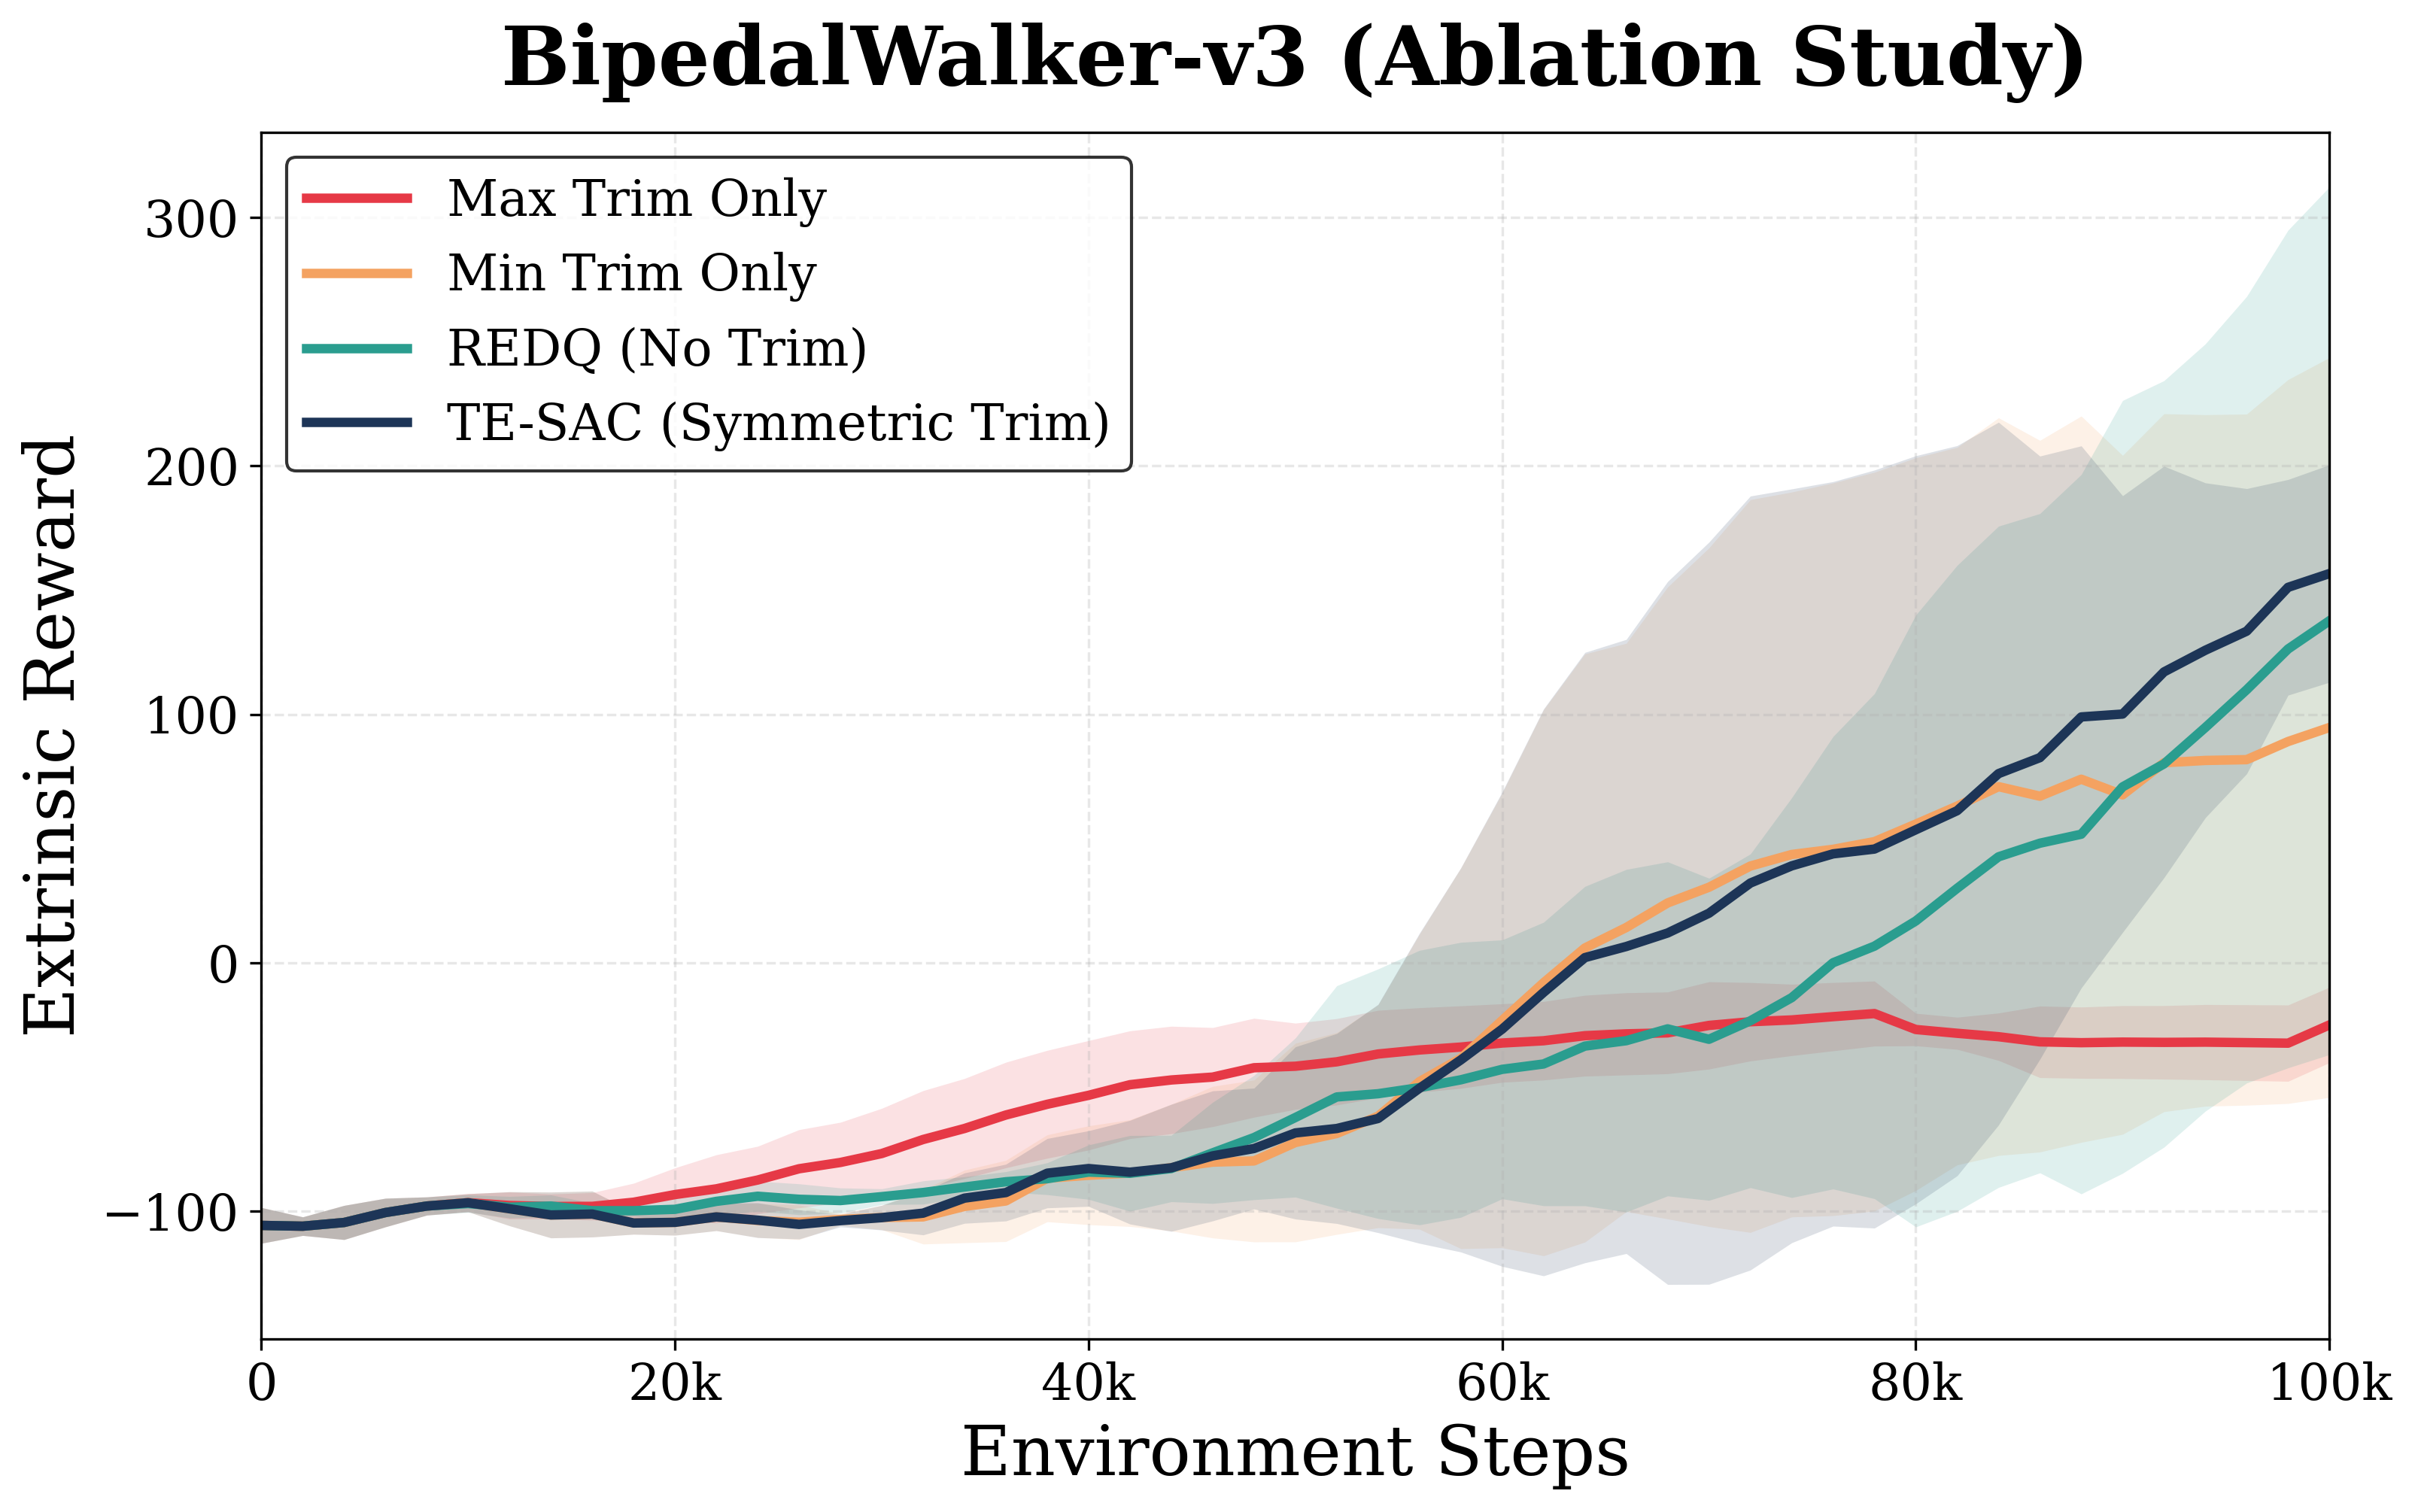

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Publication-Quality Formatting Settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 26,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'lines.linewidth': 3.0,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 3. Definitions & High-Contrast Q1 Color Palette
ALGORITHMS = {
    "Ablation_max_only": {"label": "Max Trim Only", "color": "#E63946"},
    "Ablation_min_only": {"label": "Min Trim Only", "color": "#F4A261"},
    "REDQ_Baseline": {"label": "REDQ (No Trim)", "color": "#2A9D8F"},
    "TE_SAC_UTD5": {"label": "TE-SAC (Symmetric Trim)", "color": "#1D3557"}
}

ENVIRONMENTS = ["BipedalWalker-v3"]
SEEDS = [42, 101, 2026]

MAX_STEPS = 100_000
RESOLUTION = 2_000
SMOOTHING_WINDOW = 10

# 4. Output path
OUTPUT_DIR = '/content/drive/MyDrive/Q1_Research_Data/Plots'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'ablation_plot.pdf')

def load_and_process_data(algo, env, seeds):
    grid = np.arange(0, MAX_STEPS + RESOLUTION, RESOLUTION)
    all_runs = []

    for seed in seeds:
        path = f'/content/drive/MyDrive/Q1_Research_Data/Ablation_Study/{algo}/{env}/Seed_{seed}/training_log.csv'

        if algo == "TE_SAC_UTD5" or algo == "REDQ_Baseline":
            path = f'/content/drive/MyDrive/Q1_Research_Data/{algo}/{env}/Seed_{seed}/training_log.csv'

        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                df = df.drop_duplicates(subset=['Step']).sort_values('Step')
                df = df[df['Step'] <= MAX_STEPS + RESOLUTION]

                if len(df) > 5:
                    interp_rewards = np.interp(grid, df['Step'], df['Reward'])
                    all_runs.append(interp_rewards)
            except Exception as e:
                print(f"Error loading {path}: {e}")

    if not all_runs:
        return grid, None, None

    all_runs_matrix = np.vstack(all_runs)
    df_smooth = pd.DataFrame(all_runs_matrix.T).rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()

    mean_rewards = df_smooth.mean(axis=1).values
    std_rewards = df_smooth.std(axis=1).values

    return grid, mean_rewards, std_rewards

def generate_publication_plot():
    print("Aggregating data and generating ablation plot...")

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    env = ENVIRONMENTS[0]
    ax.set_title(f"{env} (Ablation Study)", fontweight='bold', pad=15)

    for algo_key, algo_props in ALGORITHMS.items():
        steps, mean_rew, std_rew = load_and_process_data(algo_key, env, SEEDS)

        if mean_rew is not None:
            ax.plot(steps, mean_rew, label=algo_props["label"], color=algo_props["color"])
            ax.fill_between(steps,
                            mean_rew - std_rew,
                            mean_rew + std_rew,
                            color=algo_props["color"],
                            alpha=0.15,
                            linewidth=0)
        else:
            print(f"Warning: No data found for {algo_key} on {env}")

    ax.set_xlim(0, MAX_STEPS)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Extrinsic Reward")
    ax.legend(loc="upper left", frameon=True, fancybox=True, shadow=False, edgecolor='black')

    plt.tight_layout(pad=3.0)

    # Save as PDF to Drive
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(OUTPUT_PATH, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✅ Ablation plot saved to: {OUTPUT_PATH}")

    plt.show()

if __name__ == "__main__":
    generate_publication_plot()

Mounted at /content/drive
Generating Hyperparameter Sensitivity Plot...
✅ Sensitivity plot saved to: /content/drive/MyDrive/Q1_Research_Data/Plots/sensitivity_plot.pdf


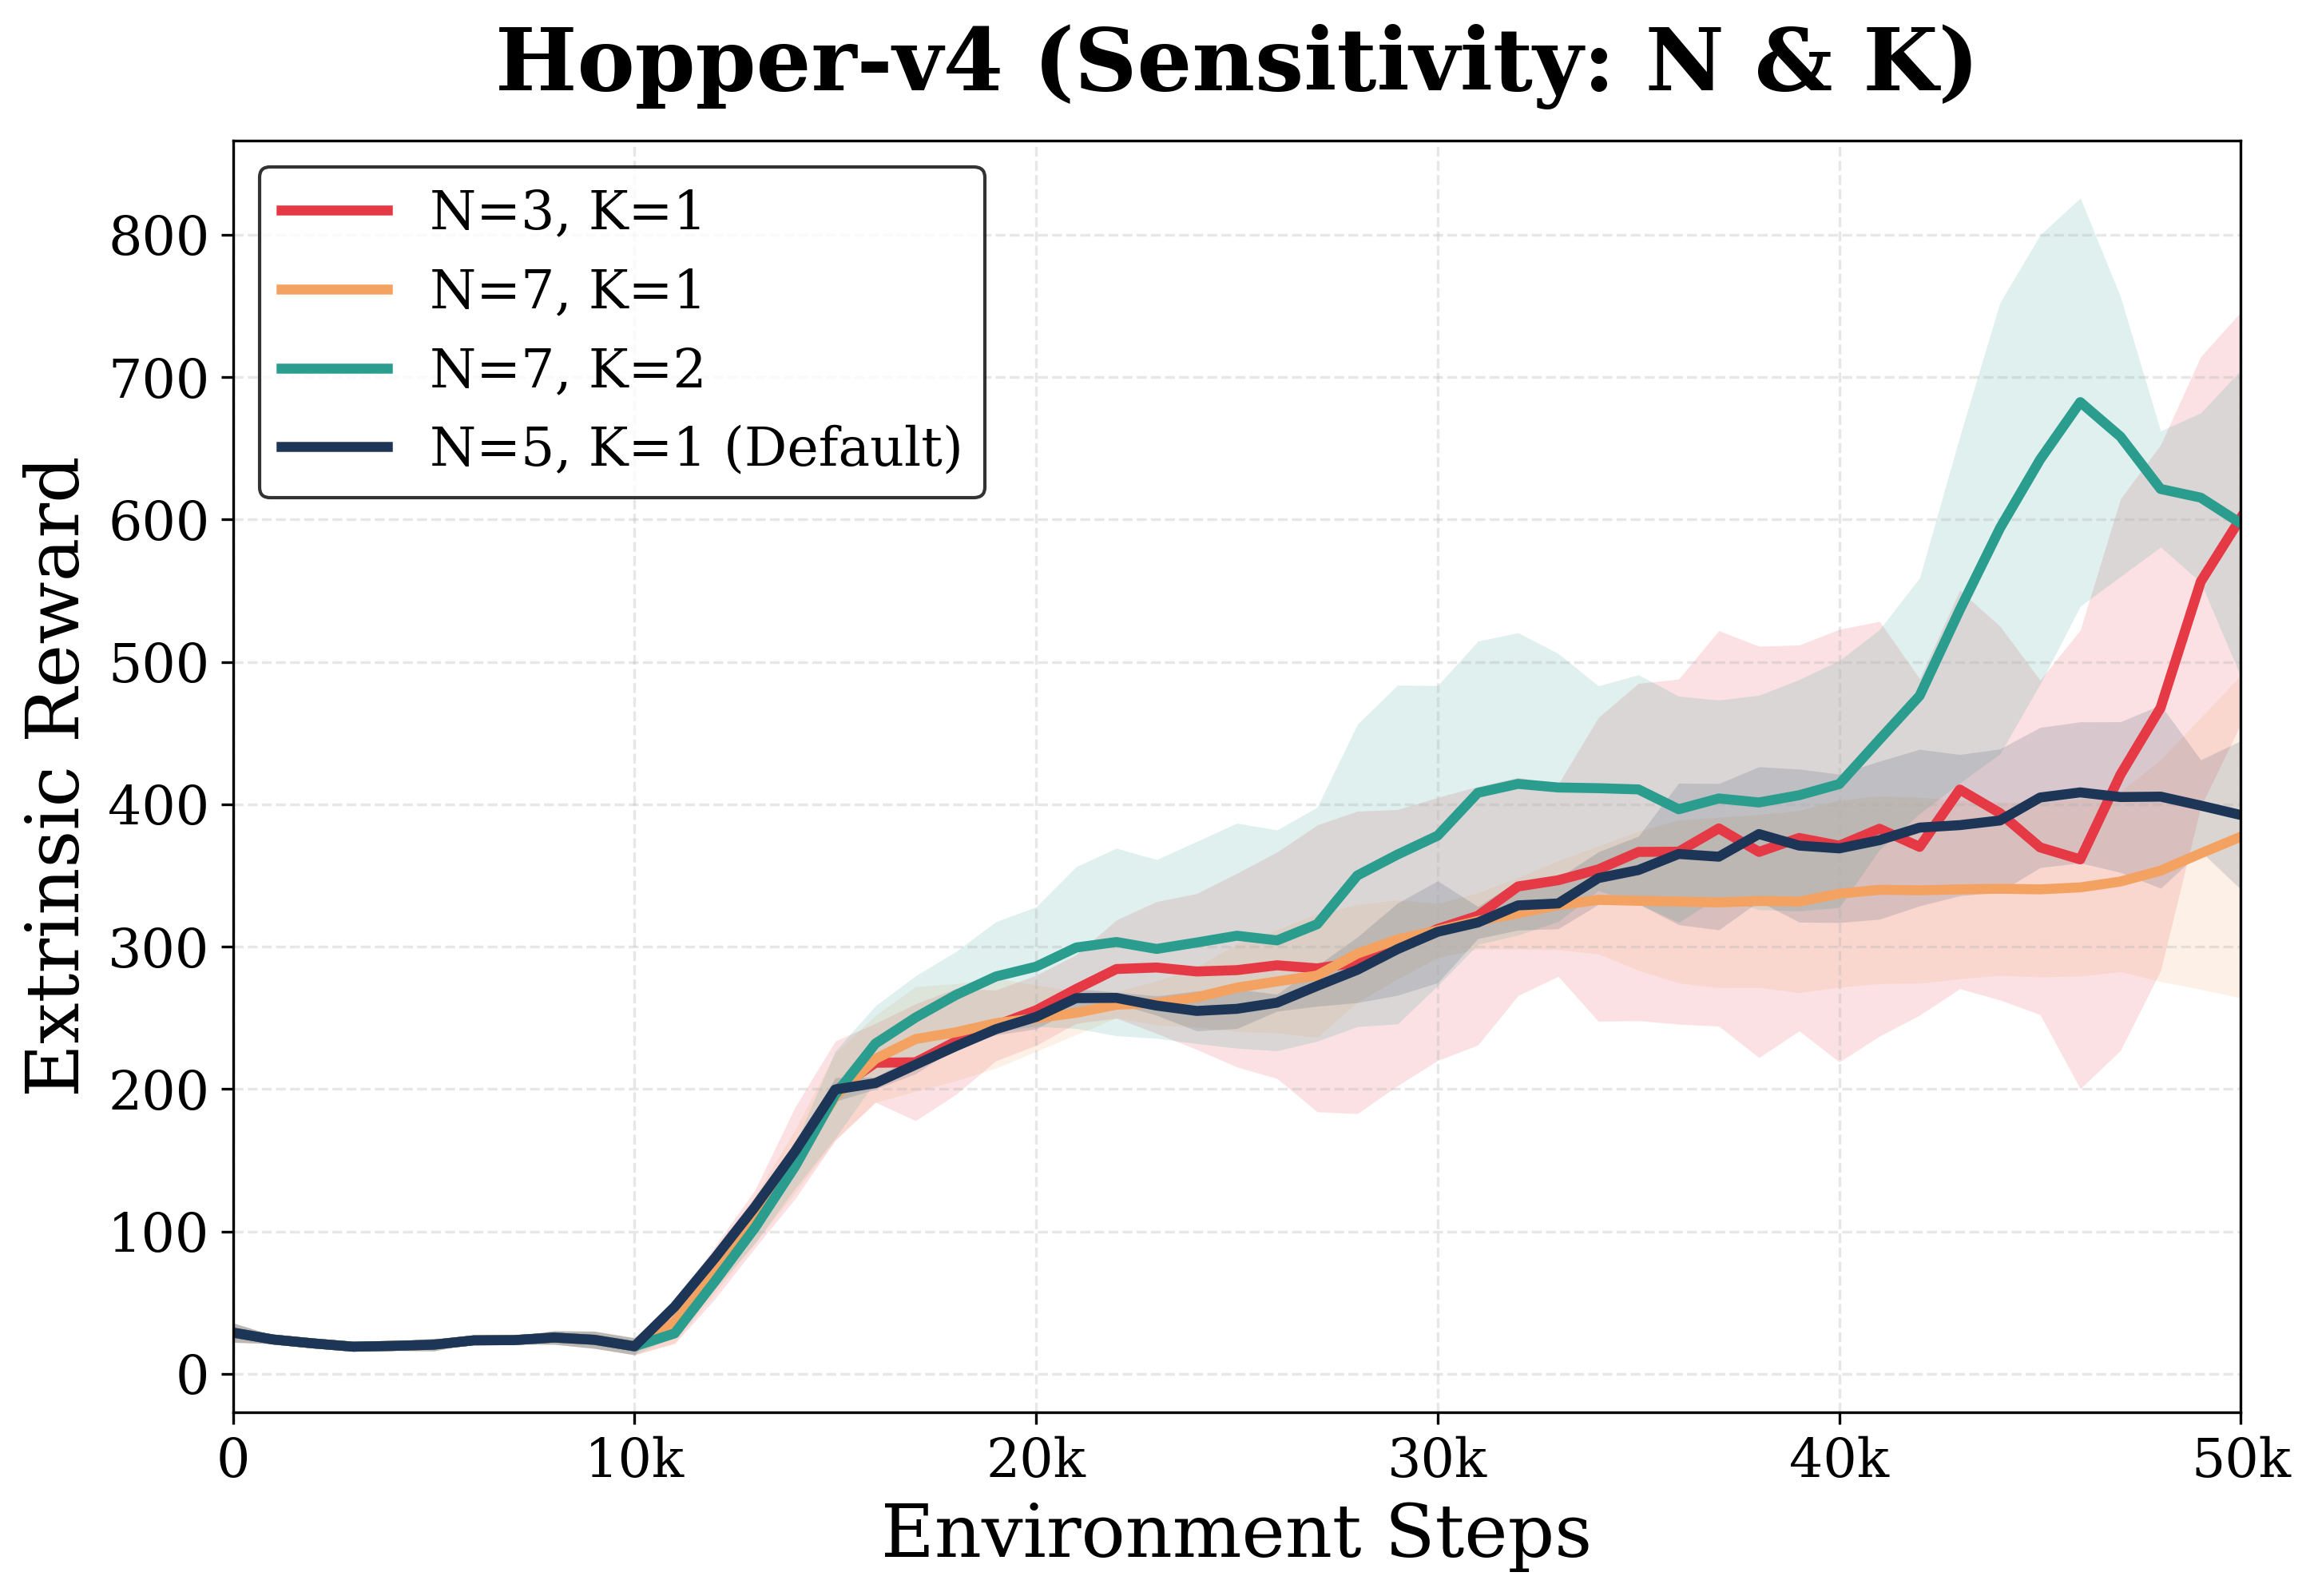

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Publication-Quality Formatting
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 26,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'lines.linewidth': 3.0,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 3. High-Contrast Palette for Sensitivity
ALGORITHMS = {
    "TE_SAC_N3_K1": {"label": "N=3, K=1", "color": "#E63946", "path_prefix": "Sensitivity_Study/"},
    "TE_SAC_N7_K1": {"label": "N=7, K=1", "color": "#F4A261", "path_prefix": "Sensitivity_Study/"},
    "TE_SAC_N7_K2": {"label": "N=7, K=2", "color": "#2A9D8F", "path_prefix": "Sensitivity_Study/"},
    "TE_SAC_UTD5":  {"label": "N=5, K=1 (Default)", "color": "#1D3557", "path_prefix": ""}
}

ENV = "Hopper-v4"
SEEDS = [42, 101, 2026]
MAX_STEPS = 50_000
RESOLUTION = 1_000
SMOOTHING_WINDOW = 5

# 4. Output path
OUTPUT_DIR = '/content/drive/MyDrive/Q1_Research_Data/Plots'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'sensitivity_plot.pdf')

def load_and_process_data(algo, path_prefix, seeds):
    grid = np.arange(0, MAX_STEPS + RESOLUTION, RESOLUTION)
    all_runs = []

    for seed in seeds:
        path = f'/content/drive/MyDrive/Q1_Research_Data/{path_prefix}{algo}/{ENV}/Seed_{seed}/training_log.csv'
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                df = df.drop_duplicates(subset=['Step']).sort_values('Step')
                df = df[df['Step'] <= MAX_STEPS + RESOLUTION]
                if len(df) > 5:
                    interp_rewards = np.interp(grid, df['Step'], df['Reward'])
                    all_runs.append(interp_rewards)
            except Exception as e:
                pass

    if not all_runs:
        return grid, None, None

    all_runs_matrix = np.vstack(all_runs)
    df_smooth = pd.DataFrame(all_runs_matrix.T).rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()
    return grid, df_smooth.mean(axis=1).values, df_smooth.std(axis=1).values

def generate_sensitivity_plot():
    print("Generating Hyperparameter Sensitivity Plot...")
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.set_title(f"{ENV} (Sensitivity: N & K)", fontweight='bold', pad=15)

    for algo_key, props in ALGORITHMS.items():
        steps, mean_rew, std_rew = load_and_process_data(algo_key, props["path_prefix"], SEEDS)
        if mean_rew is not None:
            ax.plot(steps, mean_rew, label=props["label"], color=props["color"])
            ax.fill_between(steps, mean_rew - std_rew, mean_rew + std_rew, color=props["color"], alpha=0.15, linewidth=0)
        else:
            print(f"Warning: No data for {algo_key}")

    ax.set_xlim(0, MAX_STEPS)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Extrinsic Reward")
    ax.legend(loc="upper left", frameon=True, fancybox=True, edgecolor='black')

    plt.tight_layout()

    # Save as PDF to Drive
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(OUTPUT_PATH, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✅ Sensitivity plot saved to: {OUTPUT_PATH}")

    plt.show()

if __name__ == "__main__":
    generate_sensitivity_plot()